In [ ]:
!nvidia-smi

Mon Jan 13 06:05:47 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.8/906.8 kB 51.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="0BmZngidWizdFoCpKfQz")
project = rf.workspace("apollo-yvfzk").project("floorplan-segmentation-jqpcj")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Floorplan-Segmentation-1 in yolov11:: 100%|██████████| 5900/5900 [00:01<00:00, 4538.33it/s]


In [ ]:
# Load a model
model = YOLO("yolo11n-seg.pt")

# Train the model
train_results = model.train(
    data="/content/Floorplan-Segmentation-1/data.yaml",  # path to dataset YAML
    epochs=10,  # number of training epochs
    imgsz=640,  # training image size
    device=0,  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
)

100%|██████████| 5.90M/5.90M [00:00<00:00, 210MB/s]


Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolo11n-seg.pt, data=/content/Floorplan-Segmentation-1/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_co

100%|██████████| 755k/755k [00:00<00:00, 91.9MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 293MB/s]


...

      10/10      3.84G     0.4795     0.7218     0.4671     0.8855         96        640: 100%|██████████| 152/152 [01:14<00:00,  2.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.16it/s]

                   all        243       2392      0.919      0.885      0.951       0.84      0.919      0.885      0.946      0.756



10 epochs completed in 0.233 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 6.0MB
Optimizer stripped from runs/segment/train/weights/best.pt, 6.0MB

Validating runs/segment/train/weights/best.pt...
Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n-seg summary (fused): 265 layers, 2,834,763 parameters, 0 gradients, 10.2 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:13<00:00,  1.73s/it]


                   all        243       2392      0.919      0.885      0.951       0.84      0.919      0.885      0.946      0.756
Speed: 0.4ms preprocess, 4.9ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to runs/segment/train


In [ ]:
from IPython.display import Image

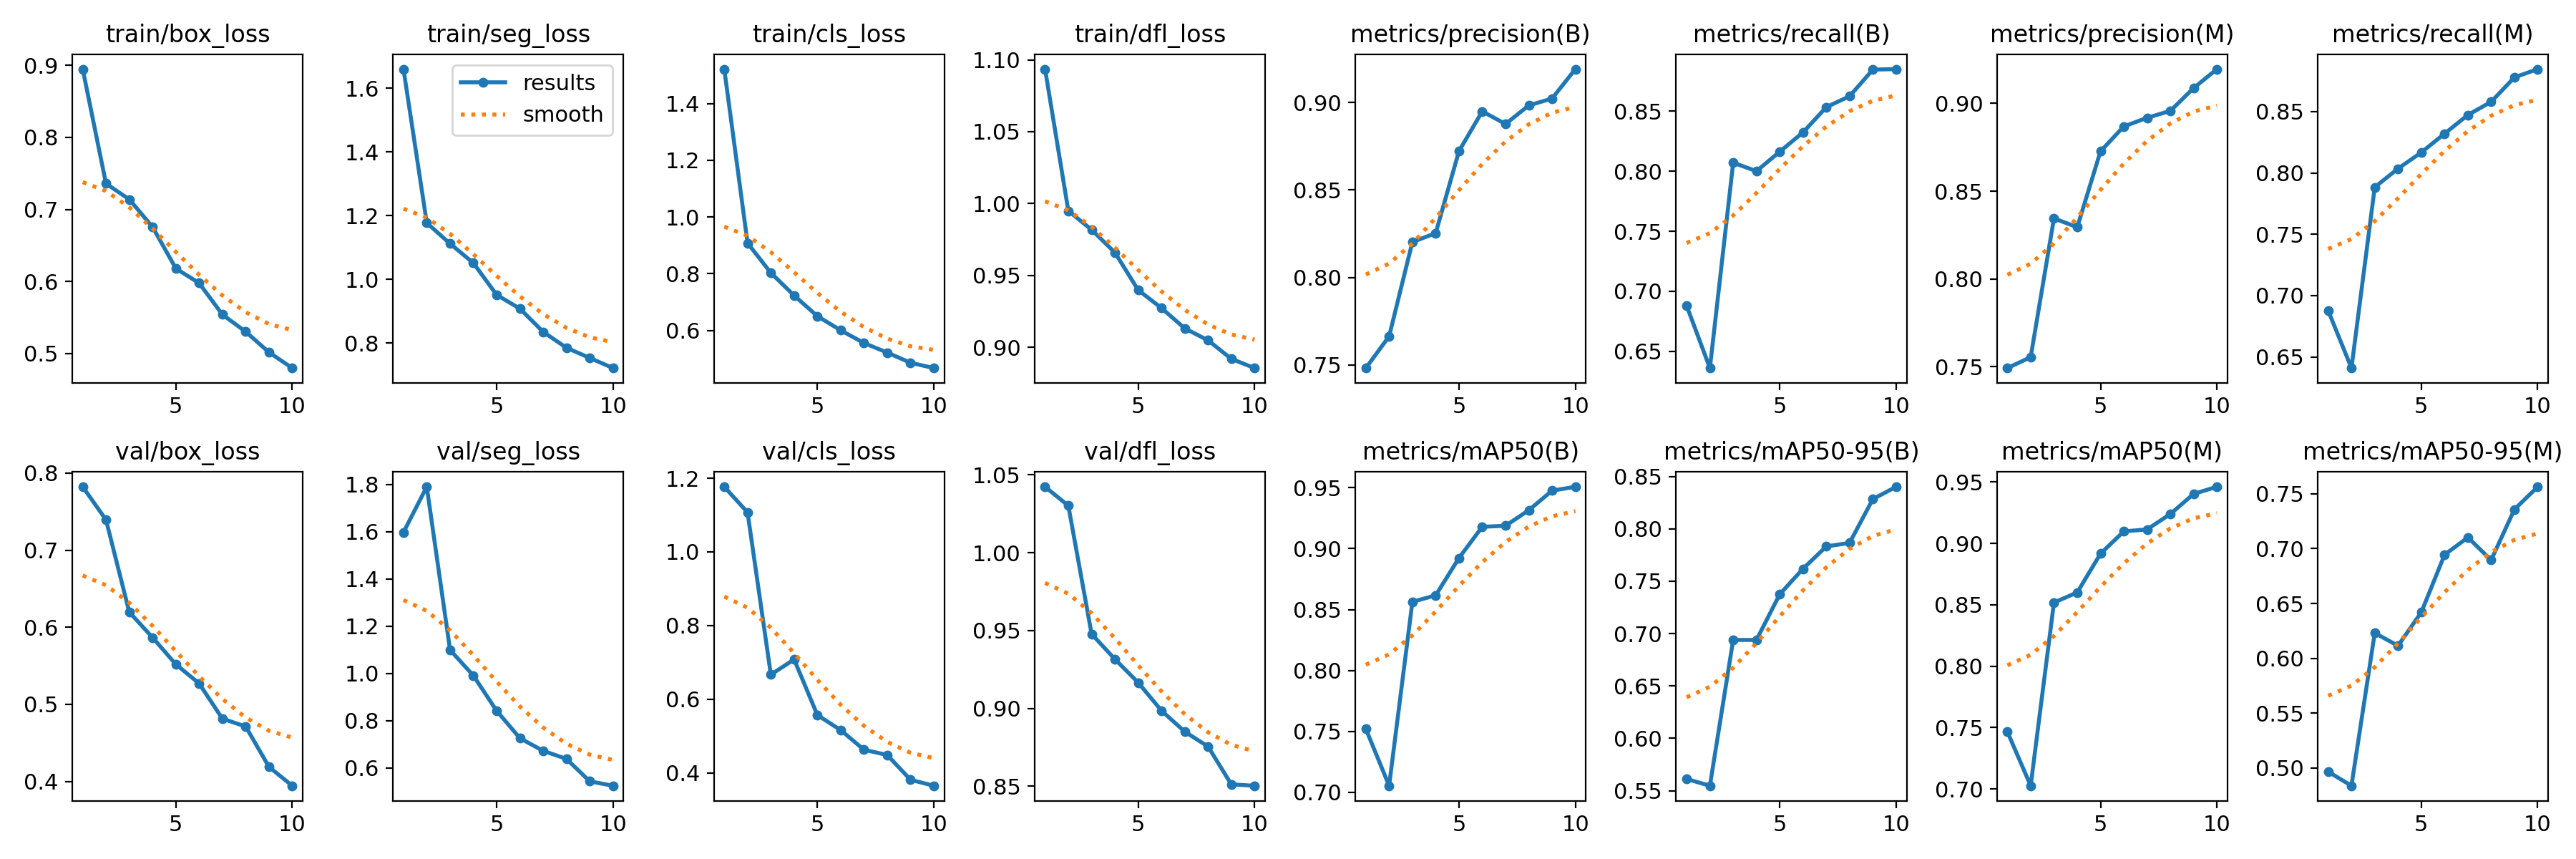

In [ ]:
Image("/content/runs/segment/train/results.png", width=1200)



image 1/1 /content/sample1.png: 640x512 5 Room Segmentation - v11 2024-09-22 12-14pms, 119.6ms
Speed: 2.6ms preprocess, 119.6ms inference, 4.4ms postprocess per image at shape (1, 3, 640, 512)
Results saved to runs/segment/predict3


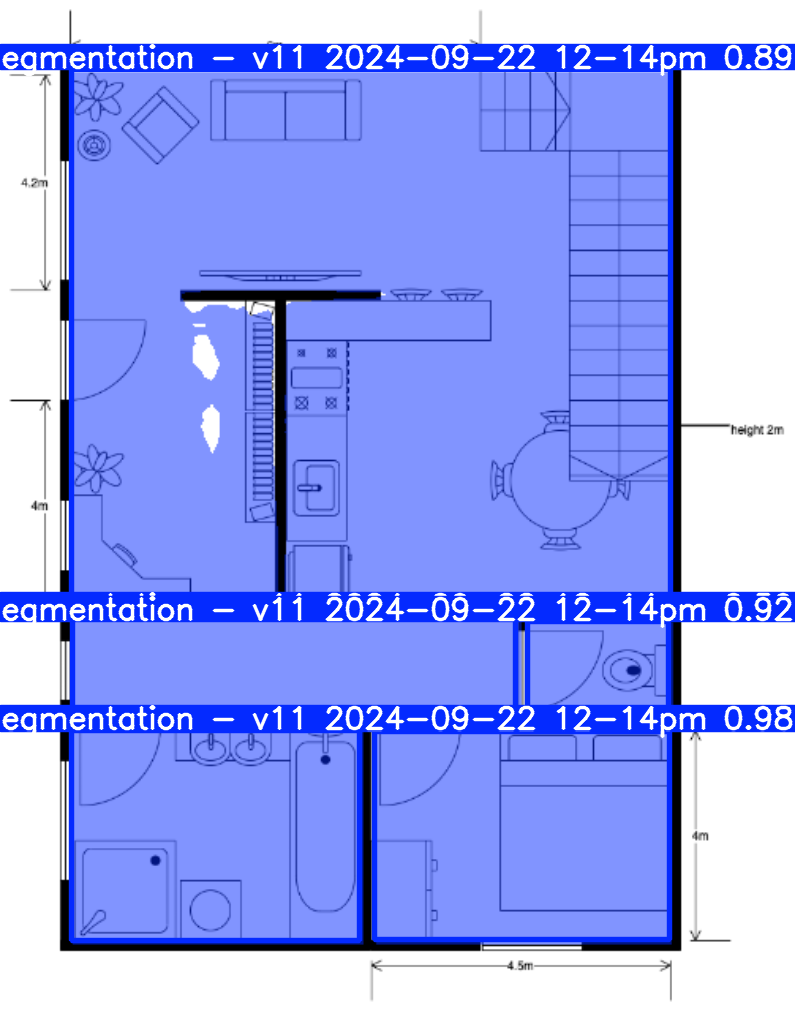

In [ ]:
model = YOLO('/content/runs/segment/train/weights/best.pt')
results = model("/content/sample1.png/", save=True)
results[0].show()


image 1/1 /content/sample2.jpg: 448x640 (no detections), 53.9ms
Speed: 2.8ms preprocess, 53.9ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs/segment/predict4


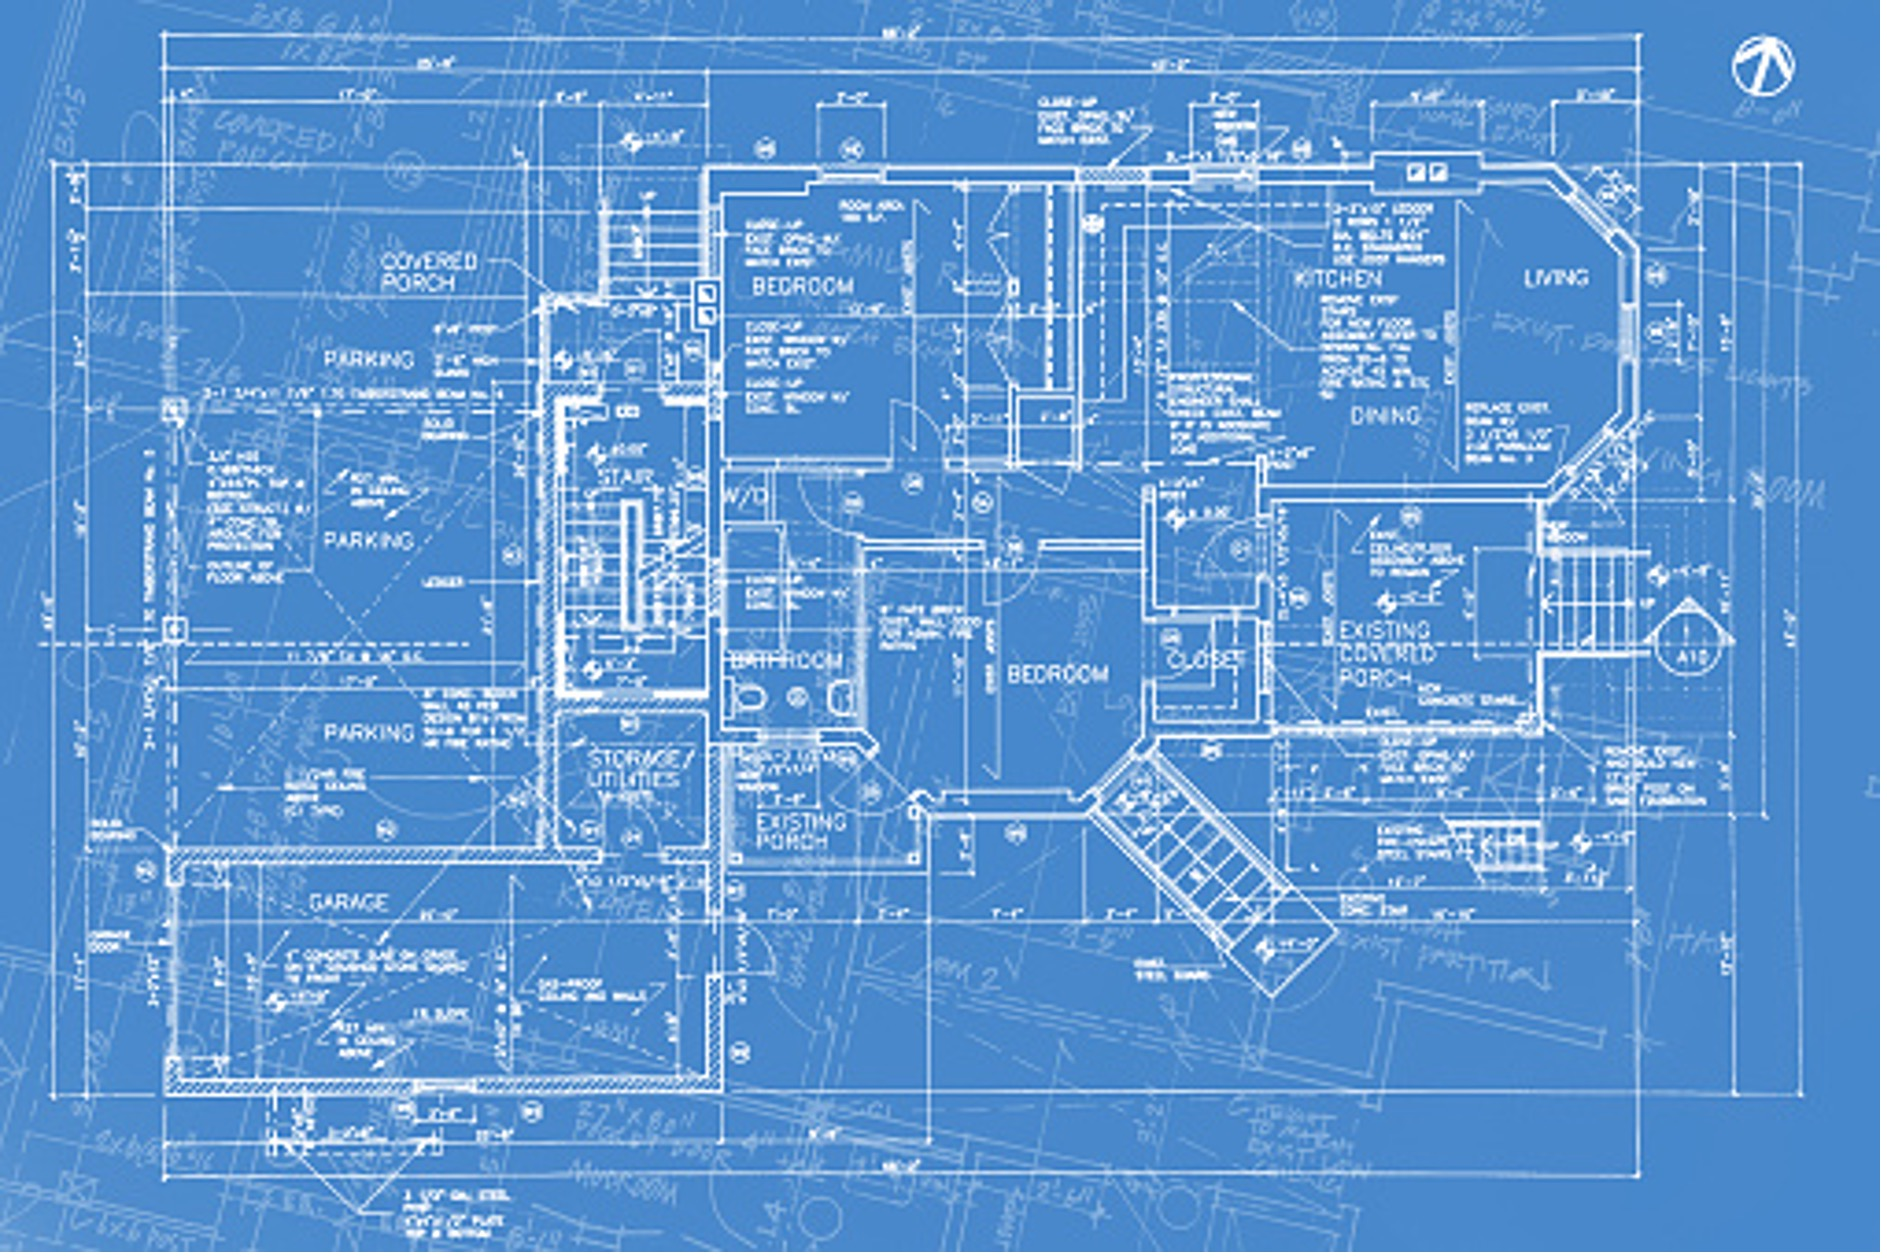

In [ ]:
model = YOLO('/content/runs/segment/train/weights/best.pt')
results = model("/content/sample2.jpg", save=True)
results[0].show()


image 1/1 /content/sample3.jpg: 640x640 39 Room Segmentation - v11 2024-09-22 12-14pms, 18.4ms
Speed: 1.7ms preprocess, 18.4ms inference, 15.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/segment/predict5


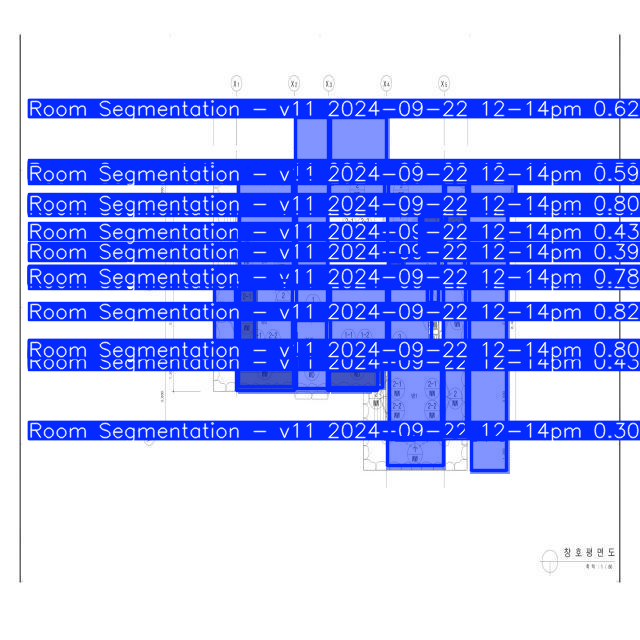

In [15]:
model = YOLO('/content/runs/segment/train/weights/best.pt')
results = model("/content/sample3.jpg", save=True)
results[0].show()